# 信用卡申请数据分析

本数据集包含过去一段时间内某银行收到的信用卡申请人的申请信息，收集的申请数据信息中包含了申请人的人口统计、就业、收入等信息。

本分析基于某银行信用卡申请数据集，聚焦业务洞察与客户画像构建，旨在通过深度挖掘申请人的人口统计、资产状况、收入就业及教育背景等多维特征，识别影响审批结果的关键风险因子与优质客户标签，建立可落地的客户分群画像体系，为风控策略优化、精准营销触达及信用评分模型开发提供数据驱动的决策支持，助力银行在扩大信用卡业务规模的同时实现风险与收益的平衡。

## 一、数据获取

In [41]:
# 导入库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [42]:
# 读取数据
df = pd.read_csv(r'Credit_card.csv')
print(df.shape)
df.head()

(1548, 19)


,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,Label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


数据集包含1548条记录和19个字段。预览数据显示了前5行，包含客户ID（Ind_ID）、性别（GENDER）、是否拥有汽车（Car_Owner）、是否拥有房产（Propert_Owner）、子女数量（CHILDREN）、年收入（Annual_income）、收入类型（Type_Income）等字段。

## 二、数据清洗

In [43]:
# 查看数据信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ind_ID           1548 non-null   int64  
 1   GENDER           1541 non-null   object 
 2   Car_Owner        1548 non-null   object 
 3   Propert_Owner    1548 non-null   object 
 4   CHILDREN         1548 non-null   int64  
 5   Annual_income    1525 non-null   float64
 6   Type_Income      1548 non-null   object 
 7   EDUCATION        1548 non-null   object 
 8   Marital_status   1548 non-null   object 
 9   Housing_type     1548 non-null   object 
 10  Birthday_count   1526 non-null   float64
 11  Employed_days    1548 non-null   int64  
 12  Mobile_phone     1548 non-null   int64  
 13  Work_Phone       1548 non-null   int64  
 14  Phone            1548 non-null   int64  
 15  EMAIL_ID         1548 non-null   int64  
 16  Type_Occupation  1060 non-null   object 
 17  Family_Members

In [44]:
# 删除无用列 
col = ['Ind_ID', 'Mobile_phone', 'Work_Phone', 'Phone', 'EMAIL_ID']
for i in col:
    df = df.drop([i], axis=1)

使用df.info()查看数据类型和非空值数量。发现部分列存在缺失值，且Ind_ID（客户ID）、Mobile_phone（手机号码）、Work_Phone（工作电话）、Phone（电话号码）、EMAIL_ID（邮箱）等字段对信用卡审批预测没有实际意义，因此删除这些列。

In [45]:
# 检查是否有重复值并删除
print(df.duplicated().sum())
df = df.drop_duplicates()

162


检查并删除数据集中的重复记录。发现并删除了162条重复记录。

In [46]:
# 查看缺失值
df.isnull().sum()

GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Type_Occupation    438
Family_Members       0
Label                0
dtype: int64

统计各字段的缺失值数量，发现：
- GENDER（性别）：7个缺失值，采用众数填充（女性F出现频率最高）
- Annual_income（年收入）：23个缺失值，采用中位数填充（162000.0）
- Birthday_count（生日计数，负值表示距离当前天数）：22个缺失值，采用中位数填充（-15611.5）
- Type_Occupation（职业类型）：438个缺失值，由于缺失值数量较多，因此后续单独处理

In [47]:
# 缺失值填充
## 众数填充
print(df['GENDER'].mode())
df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])

0    F
Name: GENDER, dtype: object


In [48]:
## 中位数填充
print(df['Annual_income'].median())
df['Annual_income'] = df['Annual_income'].fillna(df['Annual_income'].median())
print(df['Birthday_count'].median())
df['Birthday_count'] = df['Birthday_count'].fillna(df['Birthday_count'].median())

162000.0
-15611.5


In [49]:
## 单独处理
df['Type_Occupation'] = df['Type_Occupation'].fillna('Unknown')

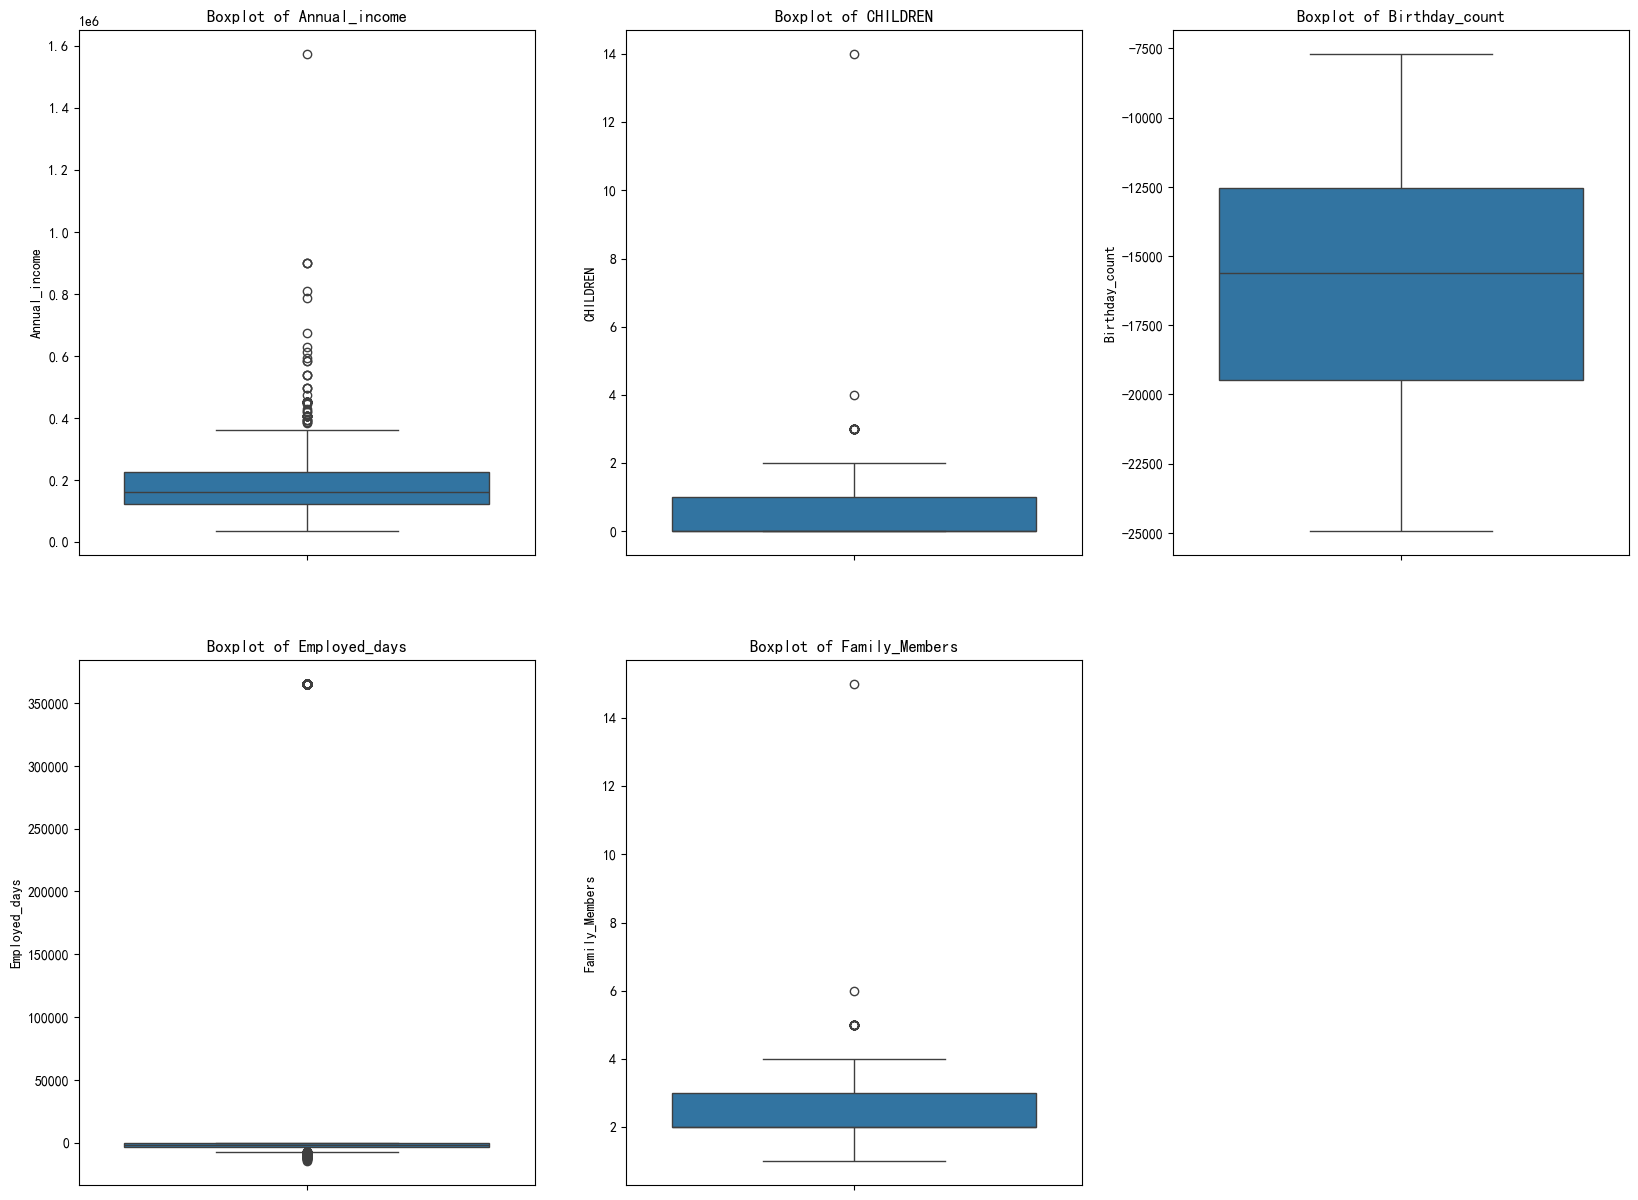

In [50]:
# 绘制箱线图来观察'Annual_income','CHILDREN','Birthday_count','Employed_days','Family_Members'是否存在异常值
columns = ['Annual_income', 'CHILDREN', 'Birthday_count', 'Employed_days', 'Family_Members']
plt.figure(figsize=(20, 15))
for i,col in enumerate(columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

绘制Annual_income（年收入）、CHILDREN（子女数）、Birthday_count（生日计数）、Employed_days（工作天数）、Family_Members（家庭成员数）五个数值变量的箱线图，识别异常值。

结果分析：
- 年收入：存在大量高值异常点，最高接近160万，但大部分数据集中在20万左右，由于现实中存在一定数量的高收入人群，因此不作处理
- 子女数量：存在极端值14个子女，远超正常范围
- 工作天数：存在365243天的异常值，推测是退休人员的数据录入存在异常，因此单独处理
- 家庭成员数：存在15人的极端值

In [51]:
# 剔除子女数量Children异常值（同时也剔除了家庭人数Family_Members异常值）
print(df['CHILDREN'].value_counts())
df = df[df['CHILDREN'] <= 3]

CHILDREN
0     967
1     280
2     121
3      16
4       1
14      1
Name: count, dtype: int64


In [52]:
# 将Birthday_count转换成Age(年龄)
df['Age'] = df['Birthday_count'].apply(lambda x: abs(int(x)) / 365)
df = df.drop('Birthday_count', axis=1)

In [53]:
df['Employed_days'].value_counts()

Employed_days
 365243    237
-460         5
-1678        5
-140         4
-586         4
          ... 
-1648        1
-3536        1
-2182        1
-1209        1
-958         1
Name: count, Length: 954, dtype: int64

In [54]:
# 增加一列表示就业状态，N表示退休，Y表示就业
df['Employment_Status'] = np.where(df['Employed_days'] > 0, 'N', 'Y')

In [55]:
# 将Employed_days转换为Employed_years
df['Employed_years'] = df['Employed_days'].apply(lambda x: -x / 365)
df = df.drop('Employed_days', axis=1)
# 将所有异常值处理成空值
df['Employed_years'] = df['Employed_years'].replace(-365243 / 365, np.nan)

In [56]:
# 将Label中的0/1变量转为分类变量
df['Label'] = df['Label'].map({0: 'approved', 1: 'rejected'}).astype('category')

由于本次分析不涉及建模预测，因此将0/1变量转为分类变量

In [57]:
# 分类变量转换
col = ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 
       'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation']
for i in col:
    df[i] = df[i].astype('category')

In [58]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1384 entries, 0 to 1547
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GENDER             1384 non-null   category
 1   Car_Owner          1384 non-null   category
 2   Propert_Owner      1384 non-null   category
 3   CHILDREN           1384 non-null   int64   
 4   Annual_income      1384 non-null   float64 
 5   Type_Income        1384 non-null   category
 6   EDUCATION          1384 non-null   category
 7   Marital_status     1384 non-null   category
 8   Housing_type       1384 non-null   category
 9   Type_Occupation    1384 non-null   category
 10  Family_Members     1384 non-null   int64   
 11  Label              1384 non-null   category
 12  Age                1384 non-null   float64 
 13  Employment_Status  1384 non-null   object  
 14  Employed_years     1147 non-null   float64 
dtypes: category(9), float64(3), int64(2), object(1)
memory usage

# 三、数据探索

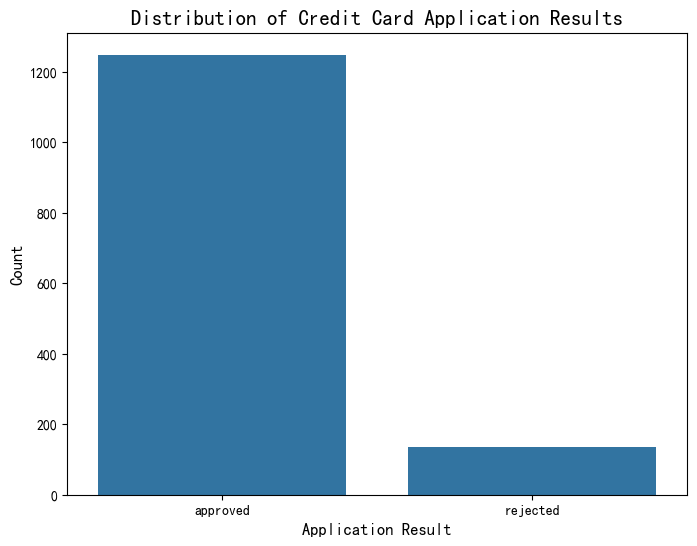

In [59]:
# 申请通过和拒绝的分布情况
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Label')
plt.title('Distribution of Credit Card Application Results', fontsize=15)
plt.xlabel('Application Result', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

通过申请约1250例，拒绝申请约130例。数据呈现严重不平衡，通过:拒绝比例约为9:1

In [60]:
# 对一些分类进行合并与修改
# 修改 Education 列中的列
df['EDUCATION'] = df['EDUCATION'].astype(str).replace('Academic degree', 'Higher education')
df['EDUCATION'] = df['EDUCATION'].astype('category')
# 修改 Marital_status 中的列
df['Marital_status'] = df['Marital_status'].astype(str).replace('Civil marriage', 'Married')
# 将多个类别合并为一个新类别
df['Marital_status'] = df['Marital_status'].replace({'Single / not married': 'not married', 'Widow': 'not married'})
df['Marital_status'] = df['Marital_status'].astype('category')
# 修改 Housing_type 列
df['Housing_type'] = df['Housing_type'].astype(str).replace('Co-op apartment', 'Rented apartment')
df['Housing_type'] = df['Housing_type'].astype('category')

对分类变量进行类别合并以简化分析：
- 教育程度：将"Academic degree"合并到"Higher education"
- 婚姻状况：将"Single"合并到"not married"，将"Civil marriage"合并到"Married"
- 住房类型：将"Co-op apartment"合并到"House /apartment"

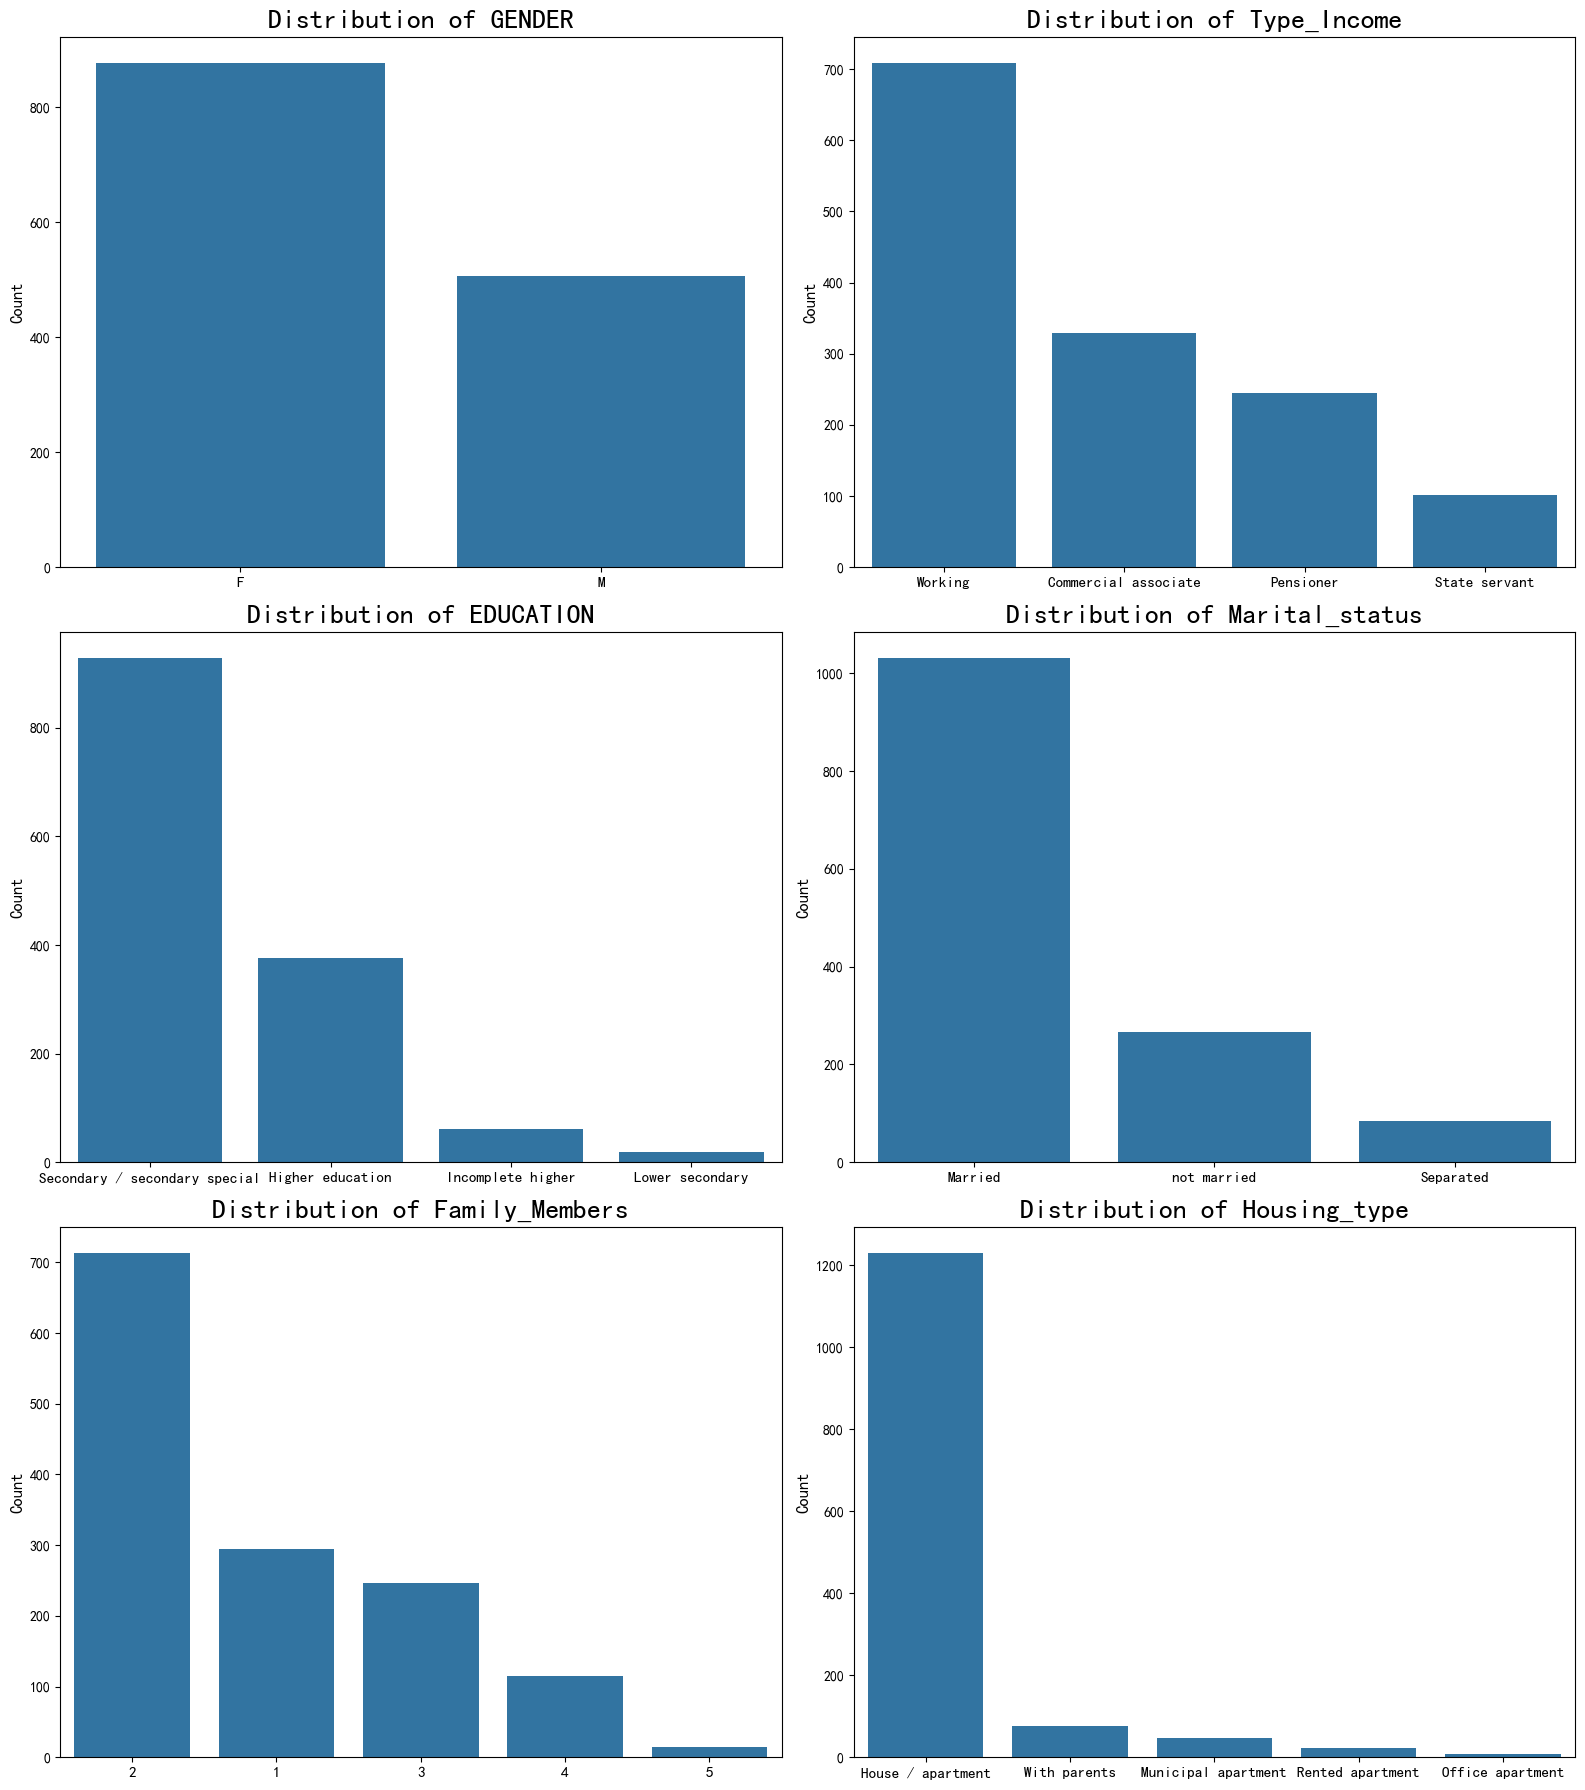

In [61]:
# 性别、收入类型、教育程度、婚姻状况这些分类变量的分布情况
cols = ['GENDER', 'Type_Income', 'EDUCATION', 'Marital_status', 'Family_Members', 'Housing_type']
plt.figure(figsize=(16, 18))
for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribution of {col}', fontsize=20) 
    plt.xlabel('')
    plt.ylabel('Count', fontsize=12)
    plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

- 性别：女性（约900人）远多于男性（约500人）
- 收入类型：工薪阶层（Working）最多（约700人），其次是商业合伙人（Commercial associate，约330人）、养老金领取者（Pensioner，约250人）、公务员（State servant，约100人）
- 教育程度：中等/中等专业教育占比最高（约950人），高等教育约380人，高等教育未完成约60人，中等以下教育极少
- 婚姻状况：已婚（Married，约1050人）占绝对主导，未婚约270人，离异约80人
- 家庭成员数：2人家庭最多（约720人），1人家庭约300人，3人家庭约250人，4人家庭约120人，5人家庭极少
- 住房类型：自有住房/公寓（House/apartment，约1250人）占绝对主导，与父母同住、市政公寓、租住公寓、办公公寓均极少

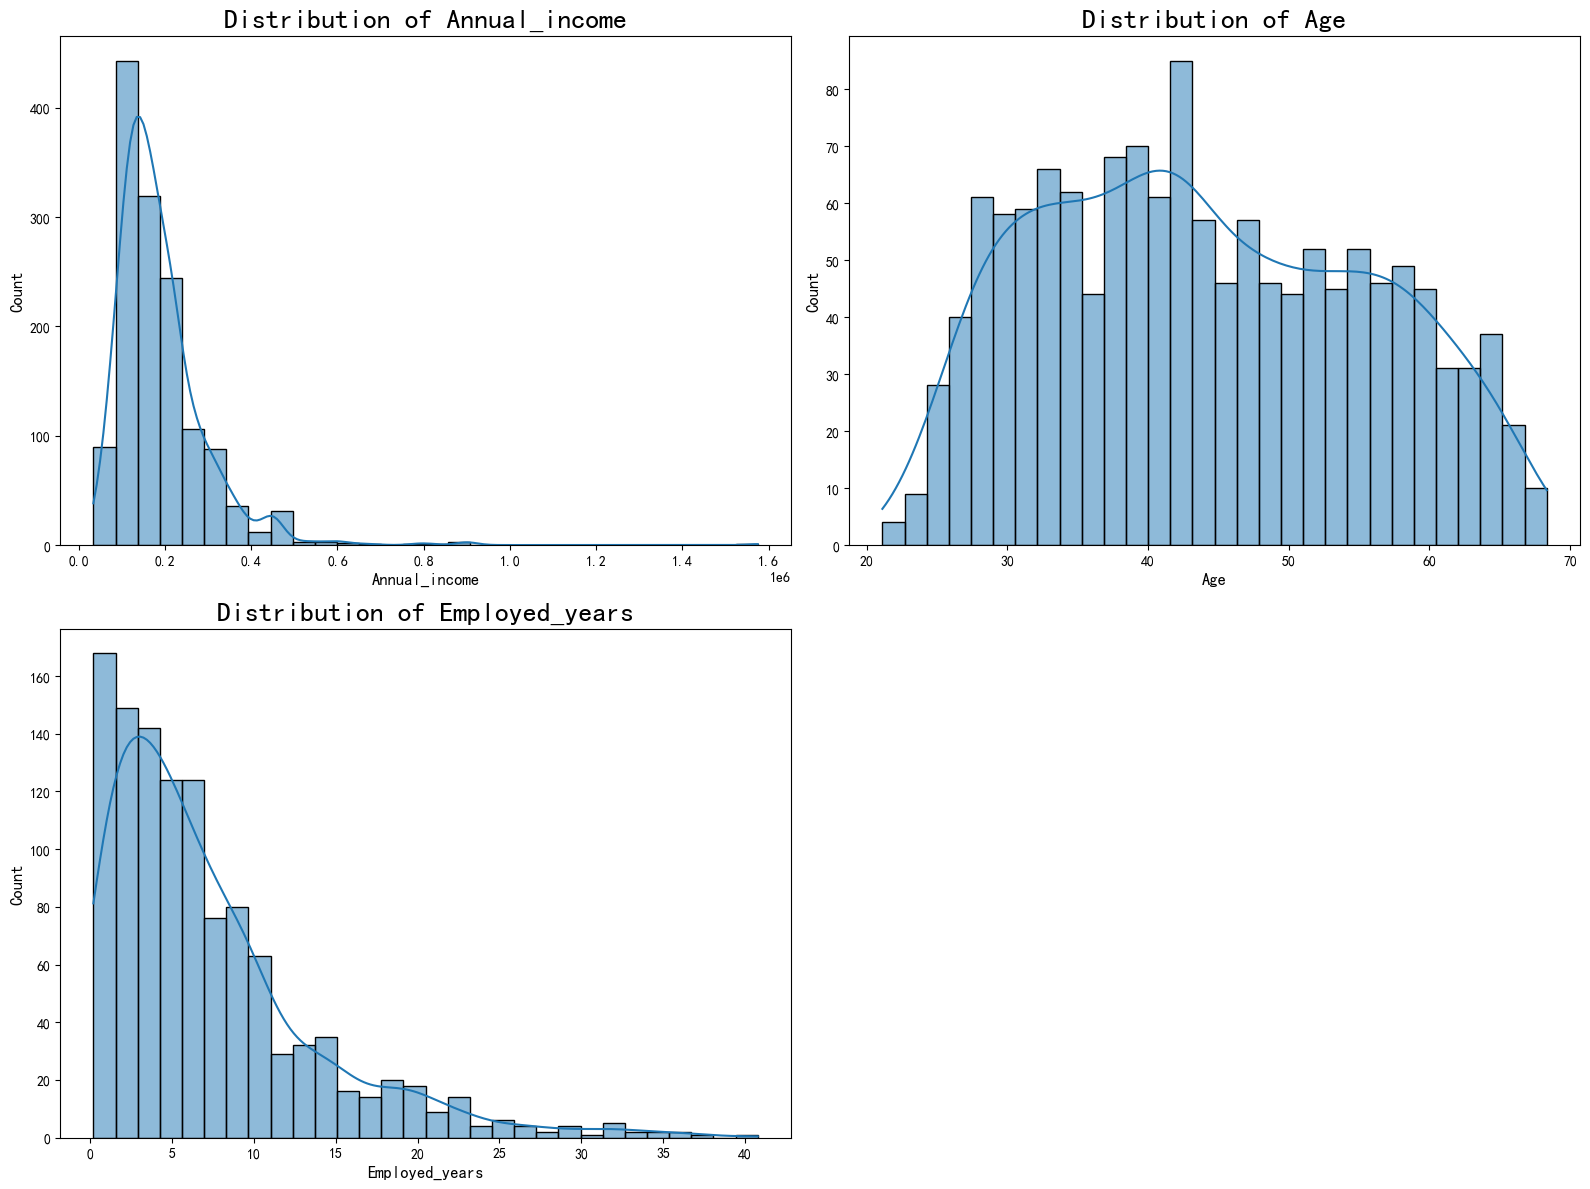

In [62]:
# 年收入、年龄、雇佣年数这些数值变量的分布情况
cols = ['Annual_income', 'Age', 'Employed_years']
plt.figure(figsize=(16, 12)) 
for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)  # 1行3列
    sns.histplot(data=df, x=col, kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=20)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

- 年收入：严重右偏分布，大部分集中在10-30万区间，存在少量高收入人群
- 年龄：近似正态分布，峰值在40岁左右，范围20-70岁，说明客户以中青年为主
- 工作年数：右偏分布，大部分客户工作年限在10年以内，随着年限增加人数递减

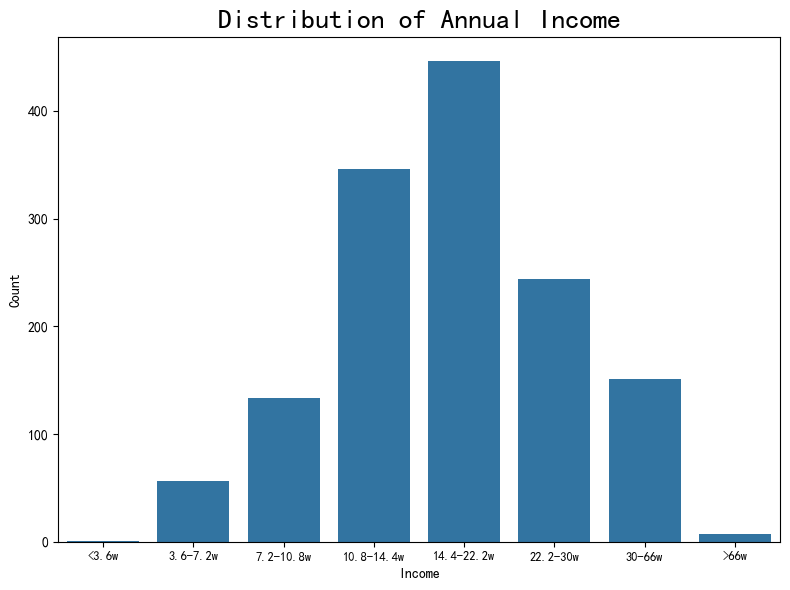

In [63]:
# 由于Annual_income受到极端值分布，对原数据进行分箱，使分布看起来更清晰
bins = [0, 36_000, 72_000, 108_000, 144_000, 222_000, 300_000, 660_000, np.inf]
labels = ['<3.6w', '3.6-7.2w', '7.2-10.8w', 
          '10.8-14.4w', '14.4-22.2w', '22.2-30w', '30-66w', '>66w']
df['income_bin'] = pd.cut(df['Annual_income'], bins=bins, labels=labels, right=False)
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='income_bin')
plt.title('Distribution of Annual Income', fontsize=20)
plt.xlabel('Income')
plt.ylabel('Count')
plt.xticks(fontsize=9)
plt.tight_layout()
plt.show()

由于年收入受极端值影响分布不均，将其分箱为8个区间，以方便分析：
- 14.4-22.2万区间人数最多（约450人）
- 其次是10.8-14.4万（约350人）和22.2-30万（约240人）
- 年收入低于3.6万的客户极少
- 高收入人群（>66万）占比很小

In [64]:
df.to_excel('Credit_card_clean.xlsx', index=False)
df.to_csv('Credit_card_clean.csv', index=False)

# 四、用户画像

### 1. 分组画像对比

In [71]:
# 分组画像对比表格
approved = df[df['Label'] == 'approved']
rejected = df[df['Label'] == 'rejected']

# 构建对比表
profile_comparison = pd.DataFrame({
    '特征': ['年龄（平均）', '年收入（平均）', '年收入（中位）', '女性占比', '有房产占比', '有汽车占比', '已婚占比', '在职占比'],
    '通过组': [
        f"{approved['Age'].mean():.1f}",
        f"{approved['Annual_income'].mean():.0f}",
        f"{approved['Annual_income'].median():.0f}",
        f"{(approved['GENDER']=='F').mean()*100:.1f}%",
        f"{(approved['Propert_Owner']=='Y').mean()*100:.1f}%",
        f"{(approved['Car_Owner']=='Y').mean()*100:.1f}%",
        f"{(approved['Marital_status']=='Married').mean()*100:.1f}%",
        f"{(approved['Employment_Status']=='Y').mean()*100:.1f}%"
    ],
    '拒绝组': [
        f"{rejected['Age'].mean():.1f}",
        f"{rejected['Annual_income'].mean():.0f}",
        f"{rejected['Annual_income'].median():.0f}",
        f"{(rejected['GENDER']=='F').mean()*100:.1f}%",
        f"{(rejected['Propert_Owner']=='Y').mean()*100:.1f}%",
        f"{(rejected['Car_Owner']=='Y').mean()*100:.1f}%",
        f"{(rejected['Marital_status']=='Married').mean()*100:.1f}%",
        f"{(rejected['Employment_Status']=='Y').mean()*100:.1f}%"
    ]
})

profile_comparison

,特征,通过组,拒绝组
0,年龄（平均）,43.7,45.6
1,年收入（平均）,187824,199820
2,年收入（中位）,162000,162000
3,女性占比,64.1%,57.4%
4,有房产占比,65.3%,62.5%
5,有汽车占比,40.1%,37.5%
6,已婚占比,75.5%,66.2%
7,在职占比,83.3%,79.4%


- 拒绝组平均年龄略高（45.6 vs 43.7）
- 两组中位年收入相同，但拒绝组平均收入更高（受极端值影响）
- 通过组的女性比例、已婚比例、在职比例均略高于拒绝组

In [66]:
# 逐行打印分类分布对比
approved = df[df['Label'] == 'approved']
rejected = df[df['Label'] == 'rejected']

def top_categories(series, top_n):
    counts = series.value_counts(normalize=True).head(top_n)
    return ', '.join([f"{cat}: {pct*100:.1f}%" for cat, pct in counts.items()])

features = ['EDUCATION', 'Type_Occupation', 'Housing_type', 'Family_Members']
feature_names = ['教育程度', '职业类型', '居住类型', '家庭人数']
top_n_list = [3, 5, 3, 3]

for col, name, n in zip(features, feature_names, top_n_list):
    if col == 'Type_Occupation':
        # 排除 Unknown 类别
        approved_series = approved[col].astype(str)
        approved_series = approved_series[approved_series != 'Unknown']
        rejected_series = rejected[col].astype(str)
        rejected_series = rejected_series[rejected_series != 'Unknown']
        approved_str = top_categories(approved_series, n)
        rejected_str = top_categories(rejected_series, n)
    else:
        approved_str = top_categories(approved[col].astype(str), n)
        rejected_str = top_categories(rejected[col].astype(str), n)
    print(f"\n【{name}】")
    print(f"  通过组 : {approved_str}")
    print(f"  拒绝组 : {rejected_str}")


【教育程度】
  通过组 : Secondary / secondary special: 67.6%, Higher education: 26.7%, Incomplete higher: 4.6%
  拒绝组 : Secondary / secondary special: 62.5%, Higher education: 31.6%, Lower secondary: 3.7%

【职业类型】
  通过组 : Laborers: 25.5%, Core staff: 16.2%, Managers: 12.3%, Sales staff: 12.0%, Drivers: 8.2%
  拒绝组 : Laborers: 24.4%, Core staff: 16.7%, Managers: 12.2%, Sales staff: 8.9%, Drivers: 6.7%

【居住类型】
  通过组 : House / apartment: 89.3%, With parents: 5.8%, Municipal apartment: 2.8%
  拒绝组 : House / apartment: 85.3%, Municipal apartment: 8.8%, Rented apartment: 2.9%

【家庭人数】
  通过组 : 2: 51.3%, 1: 21.2%, 3: 17.9%
  拒绝组 : 2: 54.4%, 1: 22.1%, 3: 16.9%


- 教育程度：通过组中等教育占67.6%，拒绝组高等教育比例略高
- 职业类型：两组分布相似，劳工、核心员工、经理为主要职业
- 居住类型：通过组自有住房比例更高（89.3% vs 85.3%）
- 家庭人数：两组均以2人家庭为主

### 2. 差异分析

In [67]:
from scipy.stats import chi2_contingency

# 需要检验的分类变量列表
cat_cols = ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 
            'EDUCATION', 'Marital_status', 'Housing_type', 'Type_Occupation',
            'Employment_Status', 'Family_Members']

# 列联分析：独立性检验
for col in cat_cols:
    obs = pd.crosstab(df[col], df['Label'])
    stat, p_value, dof, _ = chi2_contingency(obs)
    conclusion = '无显著关联' if p_value > 0.05 else '显著相关'
    print(f"{col:<18} {stat:>8.3f} {p_value:>9.4f} {dof:>6} {conclusion:>8}")

GENDER                2.127    0.1448      1    无显著关联
Car_Owner             0.256    0.6130      1    无显著关联
Propert_Owner         0.310    0.5778      1    无显著关联
Type_Income          13.201    0.0042      3     显著相关
EDUCATION             9.784    0.0205      3     显著相关
Marital_status        5.600    0.0608      2    无显著关联
Housing_type         17.732    0.0014      4     显著相关
Type_Occupation      22.030    0.2306     18    无显著关联
Employment_Status     1.019    0.3128      1    无显著关联
Family_Members        2.497    0.6451      4    无显著关联


对10个分类变量与审批结果（Label）进行卡方独立性检验，判断哪些特征与审批结果显著相关。

计算发现：收入类型、教育程度、住房类型是与信用卡审批结果显著相关的三个关键特征；婚姻状况与信用卡审批结果接近显著水平，但未达传统显著性水平（p_value<0.05），故暂不纳入后续核心特征分析。

In [68]:
from scipy.stats import ttest_ind

# 提取两组年龄数据
approved_age = df[df['Label'] == 'approved']['Age']
rejected_age = df[df['Label'] == 'rejected']['Age']

# 独立样本t检验
t_stat, p_value = ttest_ind(approved_age, rejected_age)
print('Age:')
print(f't_stat: {t_stat:.3f}')
print(f'p_value: {p_value:.4f}')
print('显著相关' if p_value < 0.05 else '无显著关联')

Age:
t_stat: -1.842
p_value: 0.0657
无显著关联


对年龄进行独立样本t检验：

结果：p_value=0.0657 > 0.05，无显著差异，但接近显著水平。虽然拒绝组平均年龄略高，但统计上不显著。

In [69]:
from scipy.stats import mannwhitneyu

# 提取两组年收入数据
approved_income = df[df['Label'] == 'approved']['Annual_income']
rejected_income = df[df['Label'] == 'rejected']['Annual_income']

# Mann-Whitney U 检验
stat, p_value = mannwhitneyu(approved_income, rejected_income)
print('Annual_income:')
print(f'U_stat: {stat:.2f}')
print(f'p_value: {p_value:.4f}')
print('显著相关' if p_value < 0.05 else '无显著关联')

Annual_income:
U_stat: 82736.50
p_value: 0.6301
无显著关联


对年收入进行Mann-Whitney U检验：

结果：p_value=0.6301 > 0.05，无显著差异。两组收入分布无统计学差异。

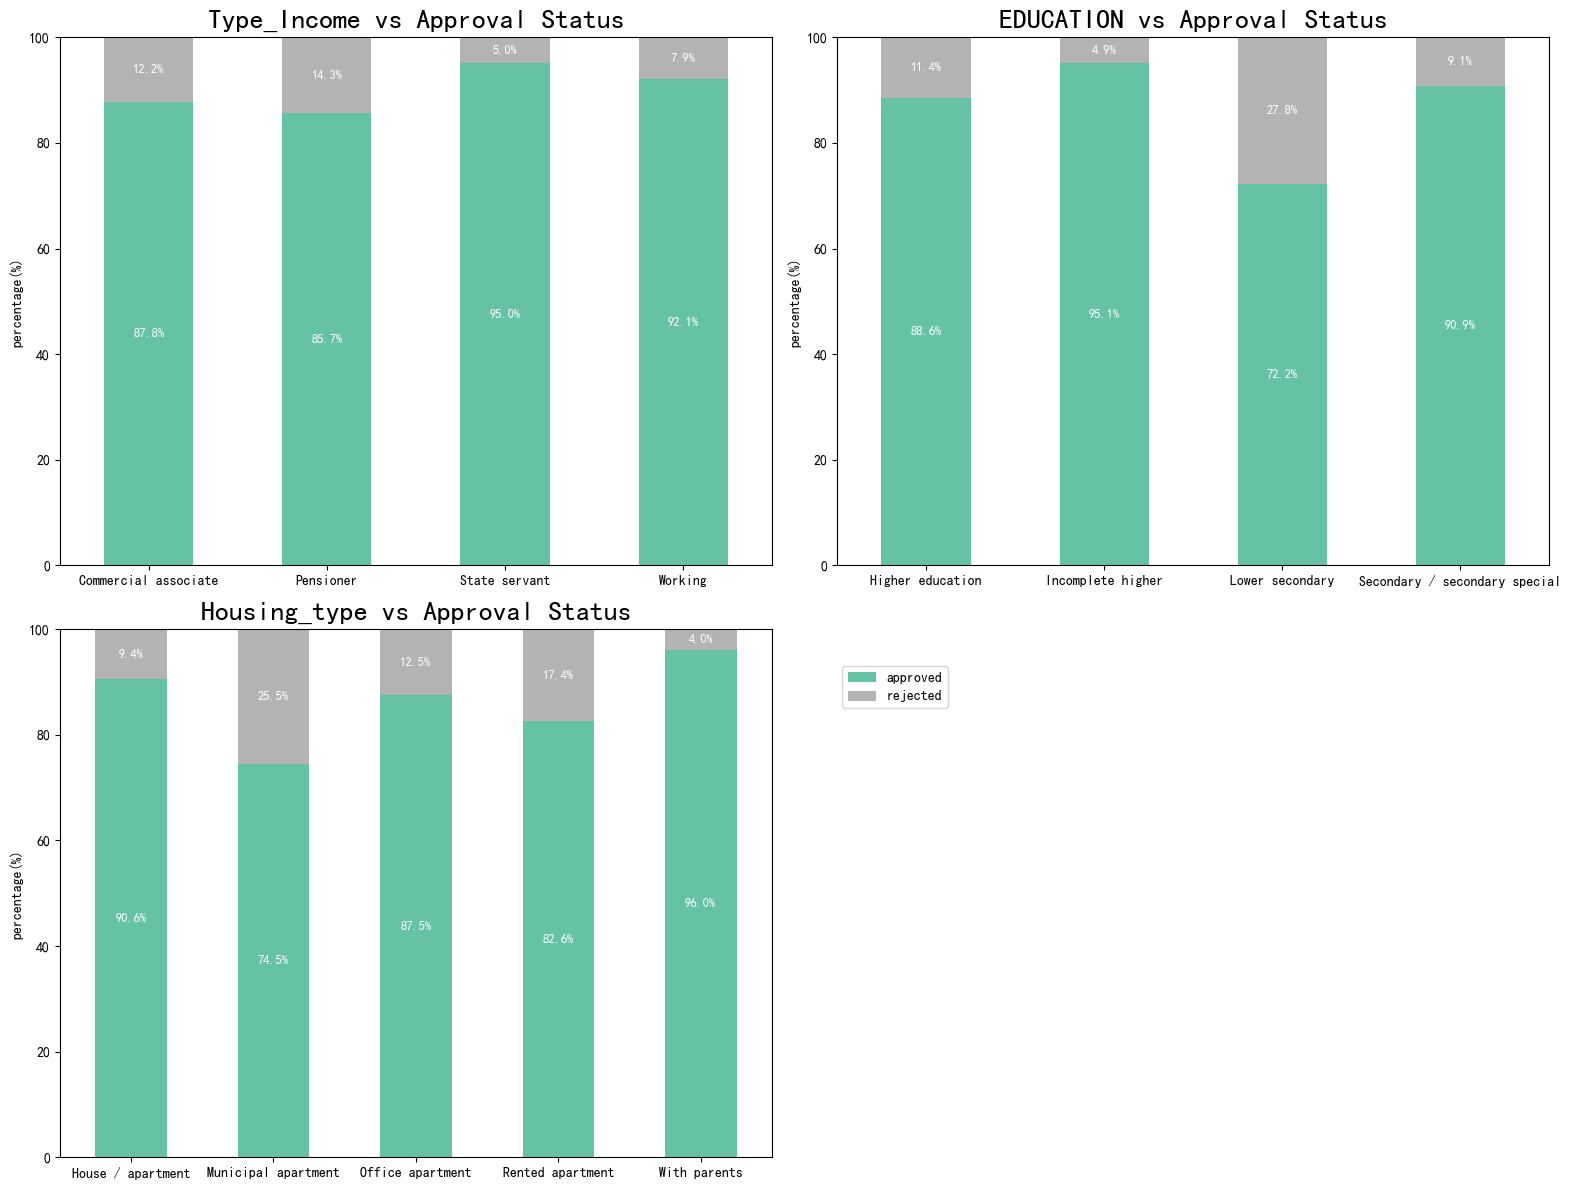

In [70]:
cols = ['Type_Income', 'EDUCATION', 'Housing_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(cols):
        col = cols[i]
        # 计算行内百分比
        ctab = pd.crosstab(df[col], df['Label'], normalize='index') * 100
        ctab.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', legend=False)
        
        # 标注百分比
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.text(p.get_x() + p.get_width()/2, p.get_y() + height/2,
                        f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white')
        
        ax.set_title(f'{col} vs Approval Status', fontsize=20)
        ax.set_xlabel('')
        ax.set_ylabel('percentage(%)')
        ax.tick_params(axis='x', rotation=0)
        ax.set_ylim(0, 100)
    else:
        ax.axis('off') 

# 统一图例
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.6, 0.4))
plt.tight_layout()
plt.show()

对三个显著相关的变量（Type_Income、EDUCATION、Housing_type）绘制堆叠百分比柱状图，展示各类别中通过/拒绝的比例。

1. 收入类型 vs 审批状态：
- 公务员（State servant）通过率最高：95.0%通过，仅5.0%拒绝
- 商业合伙人（Commercial associate）：87.8%通过，12.2%拒绝
- 工薪阶层（Working）：92.1%通过，7.9%拒绝
- 养老金领取者（Pensioner）通过率最低：85.7%通过，14.3%拒绝

关键洞察：退休人员拒绝率最高，公务员最稳定

2. 教育程度 vs 审批状态：
- 高等教育未完成（Incomplete higher）通过率最高：95.1%通过
- 高等教育（Higher education）：88.6%通过，11.4%拒绝
- 中等/中等专业教育（Secondary）：90.9%通过，9.1%拒绝
- 低等教育（Lower secondary）通过率最低：72.2%通过，27.8%拒绝

关键洞察：低教育程度群体的拒绝率是其他群体的2-3倍，是重要风险指标

3. 住房类型 vs 审批状态：
- 与父母同住（With parents）通过率最高：96.0%通过
- 办公公寓（Office apartment）：87.5%通过，12.5%拒绝
- 自有住房（House/apartment）：90.6%通过，9.4%拒绝
- 租住公寓（Rented apartment）通过率较低：82.6%通过，17.4%拒绝
- 市政公寓（Municipal apartment）通过率最低：74.9%通过，25.1%拒绝

关键洞察：租住和市政公寓居住者的拒绝率显著高于自有住房者，反映资产稳定性对审批的影响

## 五、总结

本报告通过完整的数据清洗、探索性分析和统计检验，构建了信用卡申请数据的用户画像。核心发现包括：
- 数据质量：原始数据存在重复记录、缺失值和极端异常值（如1000年的工作年限），清洗后保留1384条有效记录。
- 样本不平衡：通过:拒绝比例约为9:1。
- 显著影响因素：统计检验确认收入类型、教育程度、住房类型是与审批结果显著相关的三个核心特征，而性别、年龄、年收入、是否拥有汽车/房产等常见认知中的“重要因素”在本数据集中并未显示出统计学显著性。
- 风险人群特征：低教育程度(Lower secondary)、退休人员、居住在市政公寓或租住公寓的申请人，其拒绝率显著高于其他群体，可作为风险预警指标。
- 优质客户特征：公务员、高等教育未完成者（可能为在读高学历人群）、与父母同住的申请人通过率最高。